# Perceptron for block optimization

This code trains a neural network for block search. The block has the structure shown below. The block is defined by 18 parameters (ritational angles). However, the block is described by the 4 x 4 matrix (16 elements). Finding the matrix for given set of 18 parameters is an easy taske. The opposite task - finging 18 parameters for given 4 x 4 matrix is not that easy. Here I want to train a perceptron to do this task.

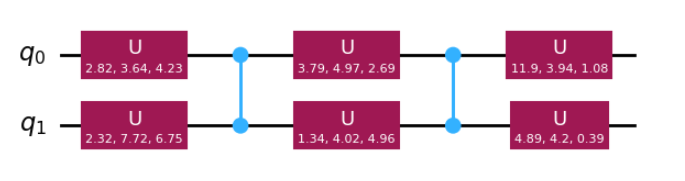

In [3]:
#import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
import numpy as np
import math
import cmath

import random
import qiskit
from qiskit.quantum_info import Operator

from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

### First I want to try 2 x 2 matrix that can be described by 3 rotating angles.

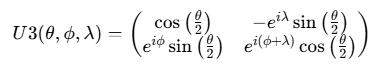

In [4]:
def rot_matr(angles):
    u = []
    u.append(math.cos(angles[0]/2))
    u.append(-1 * math.sin(angles[0]/2) * math.cos(angles[2]))
    u.append(-1 * math.sin(angles[0]/2) * math.sin(angles[2]))
    u.append(math.sin(angles[0]/2) * math.cos(angles[1]))
    u.append(math.sin(angles[0]/2) * math.sin(angles[1]))
    u.append(math.cos(angles[0]/2) * math.cos((angles[1]+angles[2])))
    u.append(math.cos(angles[0]/2) * math.sin((angles[1]+angles[2])))
    return u
    


In [18]:
#creating a dataset

import numpy as np

# Define dimensions and range
rows, cols = 5000, 3
low, high = 0, 2 * np.pi

# Generate the array
output_data = np.random.uniform(low, high, size=(rows, cols))

# Print first 5 rows as a sample
print(output_data[:1])
input_data = []
for i in range(rows):
    u = rot_matr(output_data[i])
    input_data.append(u)
print(input_data[:1])    


[[0.49628346 5.75489659 6.25904995]]
[[0.9693704920780997, -0.24553150121792927, 0.005927140789030083, 0.21212019560790052, -0.12379770475872733, 0.8251814661837632, -0.5086793673607686]]


In [19]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

X = input_data        # 4 input features
y = output_data     # 3 output classes

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for MLPs!)
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLPClassifier:
model = MLPRegressor(hidden_layer_sizes=(30, 30, 30), activation='relu', max_iter=1000)
multi_output_model = MultiOutputRegressor(model)

# Train the model
multi_output_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = multi_output_model.predict(X_test)
for i in range(3):
    print("Predicted classes:", y_pred[i])
    print("True classes:     ", y_test[i])
    print("\n")



Predicted classes: [3.04673211 4.94210211 3.87046079]
True classes:      [3.0545893  5.15312049 3.95109117]


Predicted classes: [3.96424585 4.81599071 0.43589271]
True classes:      [3.94538255 4.96638215 0.54926871]


Predicted classes: [2.55173081 2.00806367 1.80679664]
True classes:      [2.4760221  2.04894665 1.90090626]




In [20]:
dev = 0
for i in range(len(y_test)):
    dev = dev + np.linalg.norm(y_pred[i]- y_test[i])
dev = dev/len(y_test)

In [21]:
dev

0.2678631027117635

In [22]:
len(y_test)

1000

## Results of training

1. Data set size: 10^5
   hidden_layer_sizes=(20,20), activation='relu', max_iter=1000
   Deviation: 0.1

2. Data set size: 10^6
   hidden_layer_sizes=(20,20), activation='relu', max_iter=1000
   Deviation: 0.047

In [ ]:
## Now lets try the neural network trainig for the double cz block

In [21]:
def get_matrix_for_double_cz_block(params):
    qc = qiskit.QuantumCircuit(2)
    qc.u(params[0], params[1], params[2], 0)
    qc.u(params[3], params[4], params[5], 1)
    qc.cz(0, 1)
    qc.u(params[6], params[7], params[8], 0)
    qc.u(params[9], params[10], params[11], 1)
    qc.cz(0, 1)
    qc.u(params[12], params[13], params[14], 0)
    qc.u(params[15], params[16], params[17], 1)
    op = Operator(qc)
    matrix = op.data
    return matrix

def get_matrix_for_double_cz_block_red(params):
    qc = qiskit.QuantumCircuit(2)
    qc.cz(0, 1)
    qc.u(params[0], params[1], params[2], 0)
    qc.u(params[3], params[4], params[5], 1)
    qc.cz(0, 1)
    op = Operator(qc)
    matrix = op.data
    return matrix



In [22]:
pp = []
for j in range(6):
    pp.append(random.random() * 2 * np.pi)

m = get_matrix_for_double_cz_block_red(pp)

In [123]:
#creating a dataset

# Define dimensions and range
rows, cols = 1000000, 18
low, high = 0, 0.1

# Generate the array
output_data = np.random.uniform(low, high, size=(rows, cols))

# Print first 5 rows as a sample
print(output_data[0])
input_data = []
for i in range(rows):
    matr = get_matrix_for_double_cz_block(output_data[i])
    u = matr.flatten()
    flat_32 = np.empty(32)
    flat_32[0::2] = u.real
    flat_32[1::2] = u.imag
    input_data.append(flat_32)
print(u) 
print(matr)  

[0.07347823 0.06244549 0.09847518 0.01958069 0.02526178 0.03788685
 0.0293214  0.09190847 0.02829015 0.07769342 0.05023825 0.03199488
 0.05273001 0.09440515 0.09659912 0.03568263 0.03992675 0.03052996]
[ 0.99281494-6.55417070e-04j -0.10618932-1.81078784e-02j
 -0.05083524-1.11494729e-02j  0.00223482+6.80172388e-04j
  0.104746  +2.52956653e-02j  0.91273544+3.92768948e-01j
 -0.00230999-9.76139814e-04j -0.02546132-1.95042118e-02j
  0.05142746+7.22675715e-03j -0.00416802-1.10268729e-03j
  0.93550962+3.47479835e-01j -0.03264774-1.72640857e-02j
  0.00293919+9.00700289e-04j  0.02785002+1.57575447e-02j
  0.02982797+2.17943210e-02j  0.72303239+6.89076257e-01j]
[[ 0.99281494-6.55417070e-04j -0.10618932-1.81078784e-02j
  -0.05083524-1.11494729e-02j  0.00223482+6.80172388e-04j]
 [ 0.104746  +2.52956653e-02j  0.91273544+3.92768948e-01j
  -0.00230999-9.76139814e-04j -0.02546132-1.95042118e-02j]
 [ 0.05142746+7.22675715e-03j -0.00416802-1.10268729e-03j
   0.93550962+3.47479835e-01j -0.03264774-1.72640

In [118]:
flat_32

array([ 0.98389198,  0.        ,  0.09411036, -0.06899984,  0.03398237,
       -0.13011396,  0.00587437,  0.01482871,  0.11593231,  0.01332053,
       -0.85469374,  0.48738284,  0.00576572, -0.0148713 , -0.0349335 ,
       -0.12986183, -0.13228   ,  0.02421664, -0.01095443,  0.01159308,
        0.07313536, -0.98117004,  0.06181348,  0.09897895,  0.01591446,
       -0.00106257, -0.10291385,  0.08656317, -0.02190124,  0.11462144,
        0.4225028 ,  0.88855771])

In [124]:
X = input_data        # 32 input features
y = output_data     # 6 output classes

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for MLPs!)
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLPClassifier:
model = MLPRegressor(hidden_layer_sizes=(60, 60, 60), activation='relu', max_iter=10000)#'relu'
multi_output_model = MultiOutputRegressor(model)

# Train the model
multi_output_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = multi_output_model.predict(X_test)
for i in range(1):
    print("Predicted classes:", y_pred[i])
    print("True classes:     ", y_test[i])
    print("\n")

Predicted classes: [0.08843095 0.05398467 0.07151683 0.02375082 0.06193775 0.03035245
 0.07230625 0.07397149 0.05343998 0.07980811 0.05273174 0.0614662
 0.01582959 0.06056202 0.0727397  0.02631369 0.08139236 0.05845226]
True classes:      [0.08854324 0.04095824 0.0650358  0.0238246  0.02196936 0.03740219
 0.07235382 0.07865467 0.0658783  0.07978623 0.04709416 0.08889256
 0.01554785 0.01635022 0.09558099 0.02621893 0.08948163 0.04308857]


Predicted classes: [0.01190597 0.04117616 0.0567761  0.03379522 0.07372849 0.06533054
 0.01786849 0.04740364 0.04832135 0.06641311 0.04878283 0.06818972
 0.07473607 0.07635269 0.04497162 0.04835522 0.02293008 0.04525764]
True classes:      [0.01112363 0.0076824  0.07182484 0.03496066 0.09345443 0.05512112
 0.01777934 0.07060531 0.05094369 0.06649017 0.01205157 0.06165372
 0.07445862 0.08048401 0.00355041 0.04777348 0.01924768 0.0936163 ]


Predicted classes: [0.08645014 0.0436095  0.03696403 0.09602939 0.02658604 0.0588016
 0.08041515 0.03232688 0.060

In [159]:
# Predict and evaluate
y_pred = multi_output_model.predict(X_test)
for i in range(1):
    print("Predicted classes:", y_pred[i])
    print("True classes:     ", y_test[i])
    print("\n")

Predicted classes: [0.08843095 0.05398467 0.07151683 0.02375082 0.06193775 0.03035245
 0.07230625 0.07397149 0.05343998 0.07980811 0.05273174 0.0614662
 0.01582959 0.06056202 0.0727397  0.02631369 0.08139236 0.05845226]
True classes:      [0.08854324 0.04095824 0.0650358  0.0238246  0.02196936 0.03740219
 0.07235382 0.07865467 0.0658783  0.07978623 0.04709416 0.08889256
 0.01554785 0.01635022 0.09558099 0.02621893 0.08948163 0.04308857]




In [126]:
dev = 0
for i in range(len(y_test)):
    dev = dev + np.linalg.norm(y_pred[i]- y_test[i])
dev = dev/len(y_test)
dev

0.06467864507596507

### Trying quaternion reprerentation
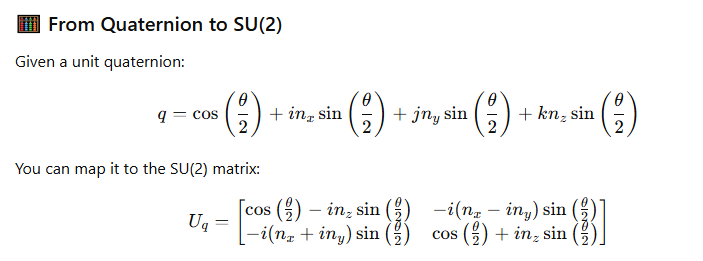

In [148]:
from qiskit.circuit.library import UnitaryGate
theta = np.pi/2
n = [0, 0, 1]
w = math.cos(theta/2)
x = n[0]*math.sin(theta/2)
y = n[1]*math.sin(theta/2)
z = n[2]*math.sin(theta/2)
U = np.array([
    [w -1j * z, -1j*(x - 1j*y)],
    [-1j*(x + 1j*y),  w +1j * z]
], dtype=complex)
gate = UnitaryGate(U, label="custom_U")
qc = qiskit.QuantumCircuit(1)
qc.append(gate, [0])  # Apply to qubit 0
qc.draw('mpl')

def u_gate_quaternion(x, y, z, w):
    U = np.array([
        [w -1j * z, -1j*(x - 1j*y)],
        [-1j*(x + 1j*y),  w +1j * z]
    ], dtype=complex)
    gate = UnitaryGate(U, label="custom_U")
    return gate

In [153]:
def get_circuit_for_double_cz_block_quatern(params):
    qc = qiskit.QuantumCircuit(2)
    gate = u_gate_quaternion(params[0], params[1], params[2], params[3])
    qc.append(gate, [0])
    gate = u_gate_quaternion(params[4], params[5], params[6], params[7])
    qc.append(gate, [1])

    qc.cz(0,1)
    
    gate = u_gate_quaternion(params[8], params[9], params[10], params[11])
    qc.append(gate, [0])
    gate = u_gate_quaternion(params[12], params[13], params[14], params[15])
    qc.append(gate, [1])

    qc.cz(0,1)
    
    gate = u_gate_quaternion(params[16], params[17], params[18], params[19])
    qc.append(gate, [0])
    gate = u_gate_quaternion(params[20], params[21], params[22], params[23])
    qc.append(gate, [1])
    
    #op = Operator(qc)
    #matrix = op.data
    return qc

def get_matrix_for_double_cz_block_quatern(params):
    qc = qiskit.QuantumCircuit(2)
    gate = u_gate_quaternion(params[0], params[1], params[2], params[3])
    qc.append(gate, [0])
    gate = u_gate_quaternion(params[4], params[5], params[6], params[7])
    qc.append(gate, [1])

    qc.cz(0,1)
    
    gate = u_gate_quaternion(params[8], params[9], params[10], params[11])
    qc.append(gate, [0])
    gate = u_gate_quaternion(params[12], params[13], params[14], params[15])
    qc.append(gate, [1])

    qc.cz(0,1)
    
    gate = u_gate_quaternion(params[16], params[17], params[18], params[19])
    qc.append(gate, [0])
    gate = u_gate_quaternion(params[20], params[21], params[22], params[23])
    qc.append(gate, [1])
    
    op = Operator(qc)
    matrix = op.data
    return matrix

def get_quaternios(params):
    quaterinons = []
    for i in range(6):
        theta_rot = params[i * 3 + 0]
        theta_n = params[i * 3 + 1]
        phi_n = params[i * 3 + 2]
        x = math.cos(theta_n) * math.cos(phi_n) * math.sin(theta_rot / 2)
        y = math.cos(theta_n) * math.sin(phi_n) * math.sin(theta_rot / 2)
        z = math.sin(theta_n) * math.sin(theta_rot / 2)
        w = math.cos(theta_rot / 2)
        quaterinons.append(x)
        quaterinons.append(y)
        quaterinons.append(z)
        quaterinons.append(w)
    return quaterinons

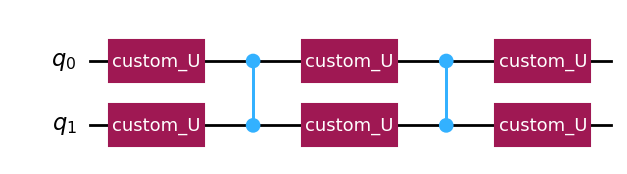

In [155]:
params = np.random.uniform(0, 2 * np.pi, size=(18))
quaterinons = get_quaternios(params)

cq = get_circuit_for_double_cz_block_quatern(quaterinons)
cq.draw('mpl')


In [167]:
#creating a dataset

# Define dimensions and range
rows, cols = 1000000, 18
low, high = 0, 2 * np.pi

# Generate the array
angles = np.random.uniform(low, high, size=(rows, cols))

input_data = []
output_data = []
for i in range(rows):
    alngles_sing = angles[i]
    quaterinons = get_quaternios(alngles_sing)
    output_data.append(quaterinons)
    matr = get_matrix_for_double_cz_block_quatern(quaterinons)
    u = matr.flatten()
    flat_32 = np.empty(32)
    flat_32[0::2] = u.real
    flat_32[1::2] = u.imag
    input_data.append(flat_32)

In [168]:
X = input_data        # 32 input features
y = output_data     # 24 output classes

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for MLPs!)
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLPClassifier:
model = MLPRegressor(hidden_layer_sizes=(20, 60, 20), activation='relu', max_iter=10000)#'relu'
multi_output_model = MultiOutputRegressor(model)

# Train the model
multi_output_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = multi_output_model.predict(X_test)
for i in range(1):
    print("Predicted classes:", y_pred[i])
    print("True classes:     ", y_test[i])
    print("\n")

Predicted classes: [ 5.63946409e-03  4.40586659e-03 -3.65159524e-05  1.91865074e-02
 -7.71219778e-03 -1.03465251e-02 -3.61675820e-04 -3.85809625e-02
  1.60231696e-03 -1.66983966e-03 -3.11043302e-04  3.06865544e-02
 -2.93711027e-03  3.68721088e-03 -9.74013935e-03  2.95647015e-04
  1.75986451e-03  1.32299695e-02 -1.38314010e-03  1.10346368e-02
 -5.77874595e-03  7.53287718e-03  3.28905313e-02  2.74915689e-02]
True classes:      [0.01636172967369865, -0.12297639890344486, 0.2738860438580251, 0.9537271801173675, 0.8221454858816651, 0.16876591433617788, -0.071561338482907, -0.5389562515058246, -0.10958438216127228, -0.2900732097907385, -0.9501350436453195, -0.03304837341136978, -0.04574582167555044, -0.029060165355363033, 0.03039961039354503, 0.998067477817341, -0.20069031708997967, 0.18261558909429132, 0.6240285863691127, 0.7327777743901865, 0.07808564557721771, 0.20956379017260388, -0.7523981822014976, -0.6195826217891881]




In [169]:
dev = 0
for i in range(len(y_test)):
    dev = dev + np.linalg.norm(y_pred[i]- y_test[i])
dev = dev/len(y_test)
dev

2.45049678800169